In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_metadata.csv
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0026232.jpg
/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1/ISIC_0027031.jpg
/kaggle/input/datasets/vrindaat/ham1000

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vrindaat/ham10000-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/vrindaat/ham10000-dataset


In [3]:
# Install required packages
!pip install scikit-image kagglehub seaborn scikit-learn matplotlib pandas numpy Pillow tqdm -q

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2

from skimage.feature import hog
from skimage import color, exposure
from skimage.transform import resize

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import itertools

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vrindaat/ham10000-dataset")
print("📁 Path to dataset files:", path)

# Walk the directory to find images and CSV
for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")
    for f in files[:10]:  # Show first 10 files per folder
        print(f"   └── {f}")
    if len(files) > 10:
        print(f"   ... and {len(files)-10} more files")

📁 Path to dataset files: /kaggle/input/datasets/vrindaat/ham10000-dataset

📂 /kaggle/input/datasets/vrindaat/ham10000-dataset
   └── HAM10000_metadata.csv

📂 /kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1
   └── ISIC_0028933.jpg
   └── ISIC_0028394.jpg
   └── ISIC_0027799.jpg
   └── ISIC_0028100.jpg
   └── ISIC_0027960.jpg
   └── ISIC_0028872.jpg
   └── ISIC_0026412.jpg
   └── ISIC_0024872.jpg
   └── ISIC_0026232.jpg
   └── ISIC_0027031.jpg
   ... and 4990 more files

📂 /kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_2
   └── ISIC_0030912.jpg
   └── ISIC_0030585.jpg
   └── ISIC_0033697.jpg
   └── ISIC_0030062.jpg
   └── ISIC_0031213.jpg
   └── ISIC_0031317.jpg
   └── ISIC_0033841.jpg
   └── ISIC_0033096.jpg
   └── ISIC_0031252.jpg
   └── ISIC_0029645.jpg
   ... and 5005 more files


In [5]:
# ── Locate metadata CSV and image folders ──────────────────────────────────
csv_path   = None
img_paths  = []   # list of directories that contain .jpg files

for root, dirs, files in os.walk(path):
    for f in files:
        full = os.path.join(root, f)
        if f.lower().endswith('.csv'):
            csv_path = full
            print(f"✅ Found CSV  : {full}")
        elif f.lower().endswith(('.jpg', '.jpeg', '.png')):
            folder = root
            if folder not in img_paths:
                img_paths.append(folder)

print(f"✅ Image dirs : {img_paths}")

# Load metadata
df = pd.read_csv(csv_path)
print(f"\n📊 Metadata shape: {df.shape}")
print(df.head())

✅ Found CSV  : /kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_metadata.csv
✅ Image dirs : ['/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_1', '/kaggle/input/datasets/vrindaat/ham10000-dataset/HAM10000_images_part_2']

📊 Metadata shape: (10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [6]:
# ── Full class name mapping ────────────────────────────────────────────────
LABEL_MAP = {
    'mel'  : 'Melanoma',
    'nv'   : 'Melanocytic Nevi',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'bkl'  : 'Benign Keratosis',
    'df'   : 'Dermatofibroma',
    'vasc' : 'Vascular Lesion'
}

# Identify the label column (dx or cell_type etc.)
label_col = 'dx' if 'dx' in df.columns else df.columns[-1]
print(f"Label column: '{label_col}'")
print(f"Unique classes: {df[label_col].unique()}")

df['class_name'] = df[label_col].map(LABEL_MAP).fillna(df[label_col])
print(df['class_name'].value_counts())

Label column: 'dx'
Unique classes: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
class_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratosis        327
Vascular Lesion          142
Dermatofibroma           115
Name: count, dtype: int64


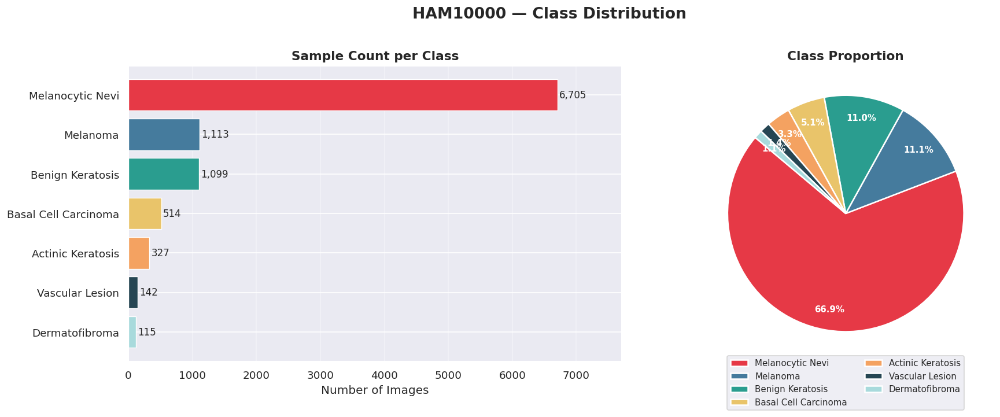

⚠️  Class Imbalance Ratio: 58.3 x


In [7]:
# ── 3.1  Class Distribution Bar + Pie ─────────────────────────────────────
class_counts = df['class_name'].value_counts()
COLORS = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#A8DADC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HAM10000 — Class Distribution', fontsize=16, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].barh(class_counts.index, class_counts.values, color=COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Sample Count per Class', fontsize=13, fontweight='bold')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
axes[0].set_xlim(0, class_counts.max() * 1.15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.4)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values, labels=None,
    autopct='%1.1f%%', startangle=140,
    colors=COLORS, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
axes[1].legend(wedges, class_counts.index, loc='lower center',
               bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('⚠️  Class Imbalance Ratio:', round(class_counts.max()/class_counts.min(), 1), 'x')

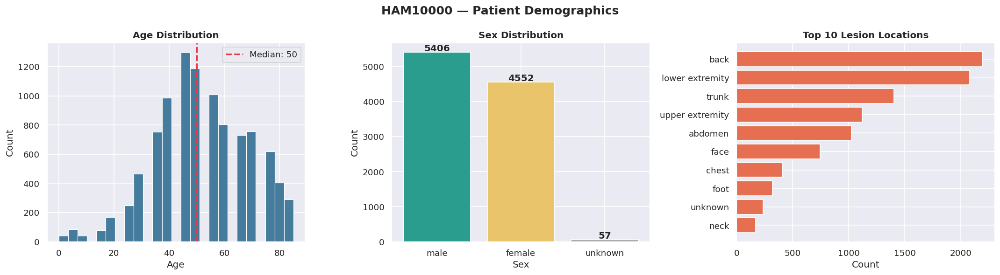

In [8]:
# ── 3.2  Age & Sex Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HAM10000 — Patient Demographics', fontsize=15, fontweight='bold')

# Age histogram
if 'age' in df.columns:
    axes[0].hist(df['age'].dropna(), bins=25, color='#457B9D', edgecolor='white', linewidth=0.7)
    axes[0].axvline(df['age'].median(), color='#E63946', linestyle='--', linewidth=2,
                    label=f"Median: {df['age'].median():.0f}")
    axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count')
    axes[0].legend()

# Sex distribution
if 'sex' in df.columns:
    sex_counts = df['sex'].value_counts()
    axes[1].bar(sex_counts.index, sex_counts.values,
                color=['#2A9D8F','#E9C46A','#aaaaaa'][:len(sex_counts)],
                edgecolor='white', linewidth=1)
    axes[1].set_title('Sex Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sex')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(sex_counts.values):
        axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Lesion location
if 'localization' in df.columns:
    loc_counts = df['localization'].value_counts().head(10)
    axes[2].barh(loc_counts.index, loc_counts.values, color='#E76F51', edgecolor='white')
    axes[2].set_title('Top 10 Lesion Locations', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Count')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('demographics.png', bbox_inches='tight', dpi=150)
plt.show()

Total images indexed: 10015


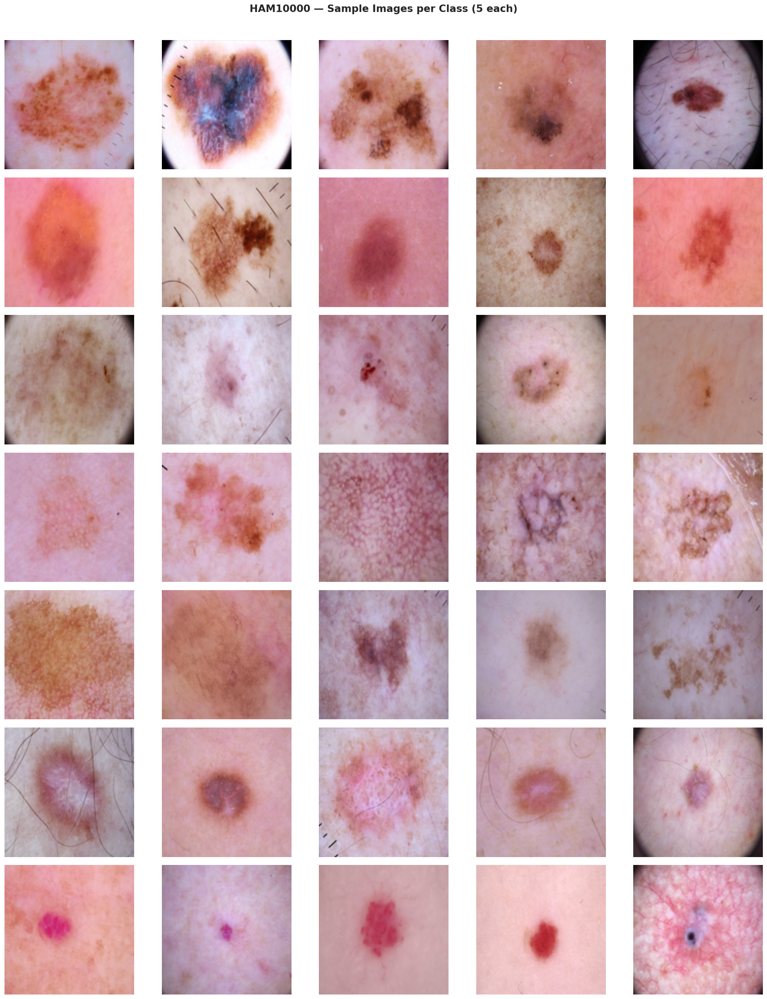

In [9]:
# ── 3.3  Sample Images from Each Class ────────────────────────────────────
# Build a lookup: image_id → full file path
id_col = 'image_id' if 'image_id' in df.columns else df.columns[0]

img_lookup = {}
for folder in img_paths:
    for fname in os.listdir(folder):
        stem = os.path.splitext(fname)[0]
        img_lookup[stem] = os.path.join(folder, fname)

print(f"Total images indexed: {len(img_lookup)}")

fig, axes = plt.subplots(7, 5, figsize=(18, 22))
fig.suptitle('HAM10000 — Sample Images per Class (5 each)', fontsize=16, fontweight='bold', y=1.01)

for row_idx, (code, name) in enumerate(LABEL_MAP.items()):
    subset = df[df[label_col] == code]
    samples = subset.sample(min(5, len(subset)), random_state=42)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx][col_idx]
        img_id = str(row[id_col])
        fpath  = img_lookup.get(img_id)
        if fpath and os.path.exists(fpath):
            img = np.array(Image.open(fpath).resize((128, 128)))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold', rotation=0,
                          labelpad=120, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', bbox_inches='tight', dpi=120)
plt.show()

In [10]:
IMG_SIZE   = 64    # Resize target (64×64 is fast for RF)
MAX_IMAGES = 3000  # Cap per run so Kaggle doesn't OOM (increase if you have RAM)

def extract_features(image_path, img_size=IMG_SIZE):
    """Extract HOG + Color Histogram features from one image."""
    img = Image.open(image_path).convert('RGB').resize((img_size, img_size))
    img_np = np.array(img)

    # ── HOG features ──
    img_gray = color.rgb2gray(img_np)
    hog_feats = hog(img_gray, orientations=8,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    feature_vector=True)

    # ── Color Histogram (each RGB channel) ──
    hist_feats = []
    for ch in range(3):
        hist, _ = np.histogram(img_np[:, :, ch], bins=32, range=(0, 256))
        hist_feats.extend(hist / hist.sum())   # normalise

    return np.concatenate([hog_feats, hist_feats])

# ── Build feature matrix ──────────────────────────────────────────────────
print(f"Extracting features for up to {MAX_IMAGES} images …")
df_sub = df.sample(min(MAX_IMAGES, len(df)), random_state=42).reset_index(drop=True)

X, y, skipped = [], [], 0
for _, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    fpath = img_lookup.get(str(row[id_col]))
    if fpath and os.path.exists(fpath):
        try:
            X.append(extract_features(fpath))
            y.append(row[label_col])
        except Exception:
            skipped += 1
    else:
        skipped += 1

X = np.array(X)
y = np.array(y)
print(f"\n✅ Features shape : {X.shape}")
print(f"   Labels shape   : {y.shape}")
print(f"   Skipped images : {skipped}")

Extracting features for up to 3000 images …


100%|██████████| 3000/3000 [00:58<00:00, 51.05it/s]


✅ Features shape : (3000, 1664)
   Labels shape   : (3000,)
   Skipped images : 0


In [11]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_
print("Classes:", class_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Compute balanced class weights to handle imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weight_dict = dict(enumerate(cw))
print("Class weights:", {class_names[k]: round(v, 2) for k, v in class_weight_dict.items()})

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Train: (2400, 1664) | Test: (600, 1664)
Class weights: {np.str_('akiec'): np.float64(4.46), np.str_('bcc'): np.float64(3.0), np.str_('bkl'): np.float64(1.22), np.str_('df'): np.float64(10.99), np.str_('mel'): np.float64(1.24), np.str_('nv'): np.float64(0.21), np.str_('vasc'): np.float64(12.99)}


In [12]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 20,
    min_samples_split = 5,
    class_weight    = class_weight_dict,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = 1
)

print("🌲 Training Random Forest …")
t0 = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - t0
print(f"✅ Training done in {train_time:.1f}s")

🌲 Training Random Forest …


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    7.0s


✅ Training done in 11.0s


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   10.9s finished


In [13]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt  = f1_score(y_test, y_pred, average='weighted')

print("=" * 55)
print("           RANDOM FOREST — TEST RESULTS")
print("=" * 55)
print(f"  Accuracy          : {acc*100:.2f}%")
print(f"  F1-Score (Macro)  : {f1_mac*100:.2f}%")
print(f"  F1-Score (Weighted): {f1_wt*100:.2f}%")
print("=" * 55)
print("\n📋 Per-Class Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_MAP.get(c, c) for c in class_names]
))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s


           RANDOM FOREST — TEST RESULTS
  Accuracy          : 67.50%
  F1-Score (Macro)  : 13.75%
  F1-Score (Weighted): 55.34%

📋 Per-Class Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.00      0.00      0.00        19
Basal Cell Carcinoma       0.00      0.00      0.00        28
    Benign Keratosis       1.00      0.09      0.16        70
      Dermatofibroma       0.00      0.00      0.00         8
            Melanoma       0.00      0.00      0.00        69
    Melanocytic Nevi       0.67      1.00      0.80       399
     Vascular Lesion       0.00      0.00      0.00         7

            accuracy                           0.68       600
           macro avg       0.24      0.16      0.14       600
        weighted avg       0.56      0.68      0.55       600



[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    0.1s finished


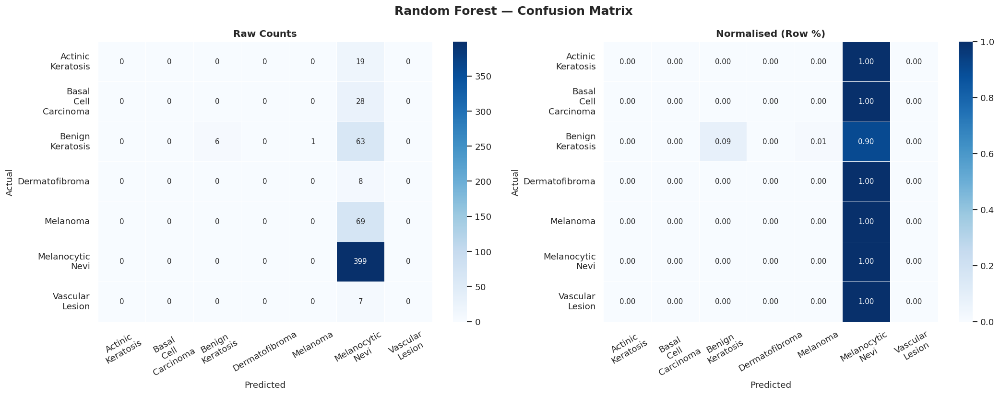

In [14]:
# ── 7.1  Confusion Matrix ─────────────────────────────────────────────────
short_names = [LABEL_MAP.get(c, c).replace(' ', '\n') for c in class_names]
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Random Forest — Confusion Matrix', fontsize=15, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw Counts', 'Normalised (Row %)']):

    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={'size': 9})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

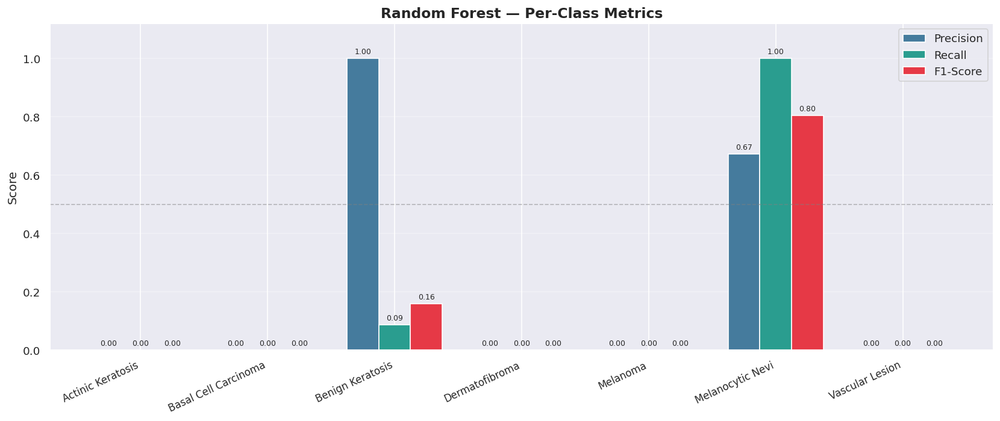

In [15]:
# ── 7.2  Per-class Precision / Recall / F1 bar chart ─────────────────────
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(class_names)))
full_names = [LABEL_MAP.get(c, c) for c in class_names]

x = np.arange(len(class_names))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w,   prec, w, label='Precision', color='#457B9D', edgecolor='white')
b2 = ax.bar(x,       rec,  w, label='Recall',    color='#2A9D8F', edgecolor='white')
b3 = ax.bar(x + w,   f1,   w, label='F1-Score',  color='#E63946', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(full_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest — Per-Class Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

Mean AUC: 0.8281


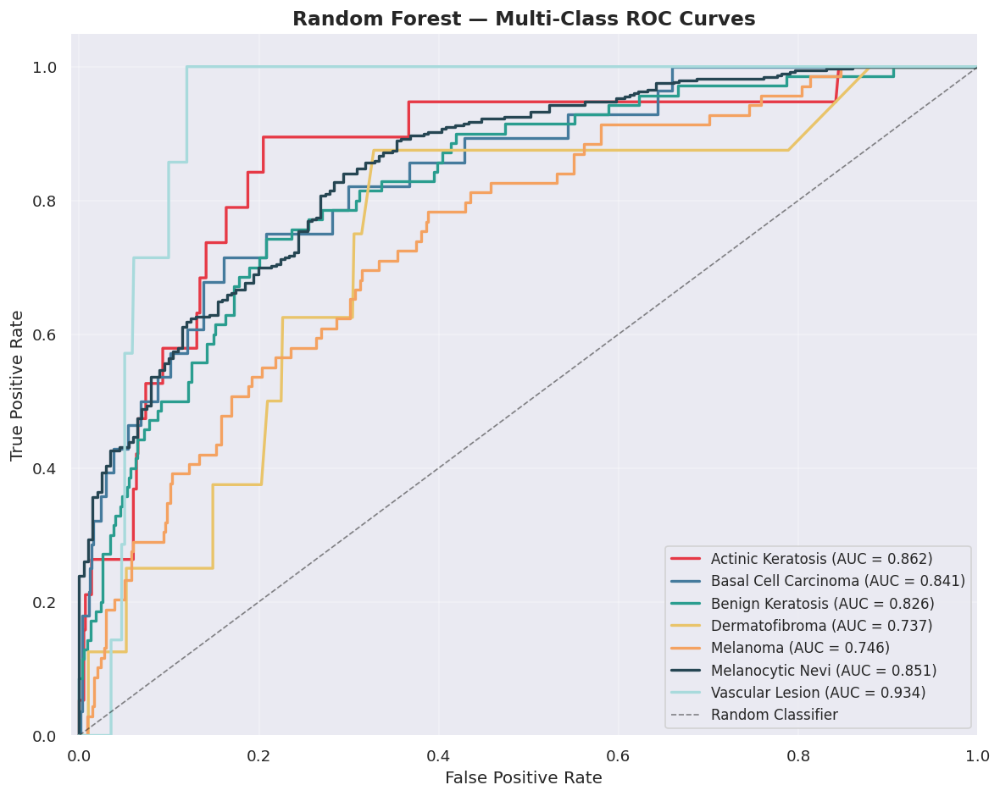

In [16]:
# ── 7.3  Multi-Class ROC Curves ───────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(10, 8))
ROC_COLORS = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#A8DADC']

auc_scores = []
for i, (cls, clr) in enumerate(zip(class_names, ROC_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=clr, lw=2,
            label=f"{LABEL_MAP.get(cls, cls)} (AUC = {roc_auc:.3f})")

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([ 0.0,  1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('Random Forest — Multi-Class ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
print(f"Mean AUC: {np.mean(auc_scores):.4f}")

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

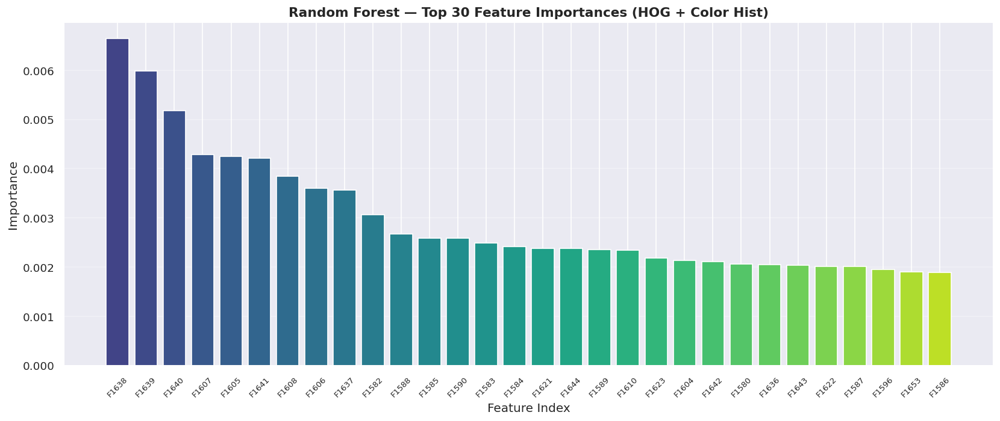

In [17]:
# ── 7.4  Feature Importance (Top 30) ─────────────────────────────────────
importances = rf_model.feature_importances_
top_k       = 30
top_idx     = np.argsort(importances)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(top_k), importances[top_idx],
       color=plt.cm.viridis(np.linspace(0.2, 0.9, top_k)),
       edgecolor='white')
ax.set_xticks(range(top_k))
ax.set_xticklabels([f'F{i}' for i in top_idx], rotation=45, fontsize=8)
ax.set_xlabel('Feature Index', fontsize=12)
ax.set_ylabel('Importance',    fontsize=12)
ax.set_title('Random Forest — Top 30 Feature Importances (HOG + Color Hist)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

Running 5-Fold Stratified Cross-Validation … (may take a few minutes)


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   18.2s finished


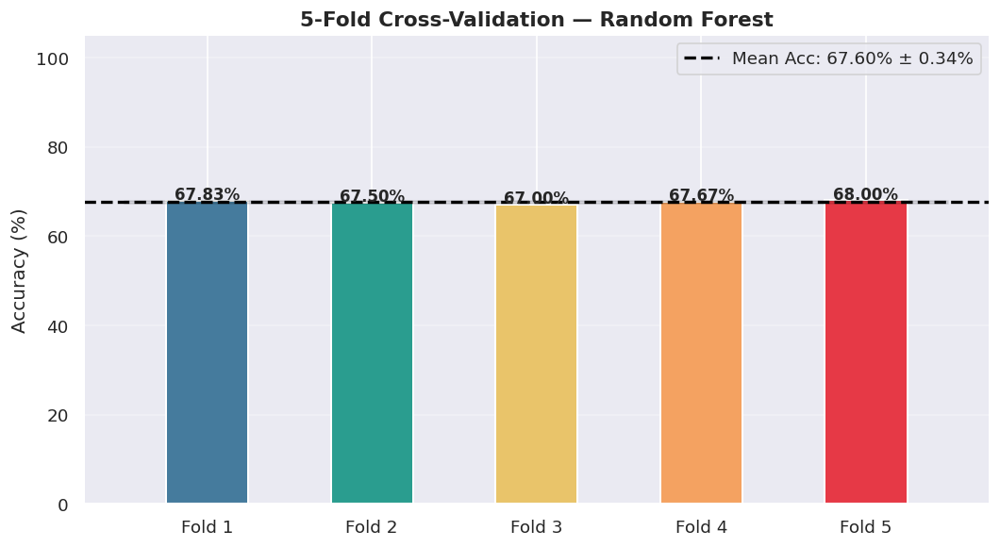

CV Scores: [0.6783 0.675  0.67   0.6767 0.68  ]
Mean: 0.6760  Std: 0.0034


In [18]:
# ── 7.5  Cross-Validation Scores ─────────────────────────────────────────
print("Running 5-Fold Stratified Cross-Validation … (may take a few minutes)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use a lighter RF for CV speed
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15,
                                class_weight=class_weight_dict,
                                random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_cv, X_scaled, y_enc, cv=skf, scoring='accuracy', verbose=1)

fig, ax = plt.subplots(figsize=(9, 5))
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(fold_labels, cv_scores * 100,
              color=['#457B9D','#2A9D8F','#E9C46A','#F4A261','#E63946'],
              edgecolor='white', linewidth=1.2, width=0.5)
ax.axhline(cv_scores.mean()*100, color='black', linestyle='--', linewidth=2,
           label=f"Mean Acc: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
ax.fill_between([-0.5, 4.5],
                [(cv_scores.mean()-cv_scores.std())*100]*2,
                [(cv_scores.mean()+cv_scores.std())*100]*2,
                alpha=0.1, color='black')
for bar, sc in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{sc*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('5-Fold Cross-Validation — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

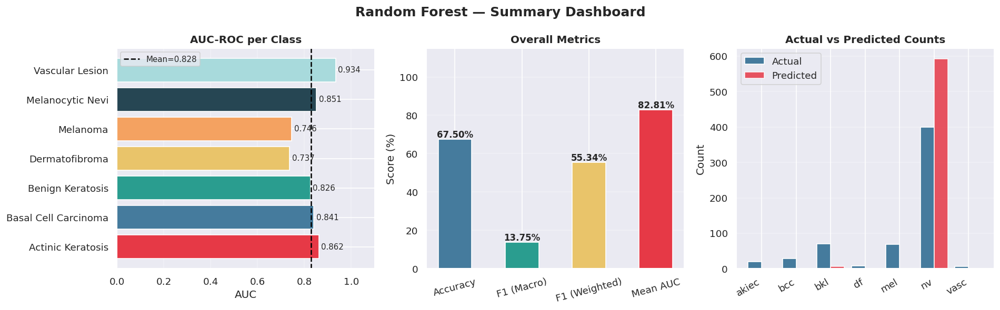

In [19]:
# ── 7.6  Summary Dashboard ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Random Forest — Summary Dashboard', fontsize=15, fontweight='bold')

# AUC per class
axes[0].barh([LABEL_MAP.get(c, c) for c in class_names],
             auc_scores, color=ROC_COLORS, edgecolor='white')
axes[0].axvline(np.mean(auc_scores), color='black', linestyle='--', linewidth=1.5,
                label=f'Mean={np.mean(auc_scores):.3f}')
axes[0].set_xlim(0, 1.1)
axes[0].set_title('AUC-ROC per Class', fontweight='bold')
axes[0].set_xlabel('AUC')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(auc_scores):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Overall metrics
metric_names  = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Mean AUC']
metric_values = [acc, f1_mac, f1_wt, np.mean(auc_scores)]
bar_colors    = ['#457B9D','#2A9D8F','#E9C46A','#E63946']
bars = axes[1].bar(metric_names, [v*100 for v in metric_values],
                   color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 115)
axes[1].set_title('Overall Metrics', fontweight='bold')
axes[1].set_ylabel('Score (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Predicted vs Actual class counts
pred_counts   = pd.Series(y_pred).value_counts().sort_index()
actual_counts = pd.Series(y_test).value_counts().sort_index()
x = np.arange(len(class_names))
axes[2].bar(x - 0.2, actual_counts.values, 0.4,
            label='Actual', color='#457B9D', edgecolor='white')
axes[2].bar(x + 0.2, pred_counts.reindex(x, fill_value=0).values, 0.4,
            label='Predicted', color='#E63946', edgecolor='white', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=30, ha='right')
axes[2].set_title('Actual vs Predicted Counts', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('summary_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

In [20]:
results = {
    'Model'               : 'Random Forest',
    'Features'            : 'HOG + Color Histogram',
    'Image Size'          : f'{IMG_SIZE}x{IMG_SIZE}',
    'n_estimators'        : 300,
    'Training Samples'    : X_train.shape[0],
    'Test Samples'        : X_test.shape[0],
    'Feature Dimensions'  : X.shape[1],
    'Training Time (s)'   : round(train_time, 2),
    'Test Accuracy (%)'   : round(acc * 100, 2),
    'F1 Macro (%)'        : round(f1_mac * 100, 2),
    'F1 Weighted (%)'     : round(f1_wt * 100, 2),
    'Mean AUC-ROC'        : round(np.mean(auc_scores), 4),
    'CV Mean Acc (%)'     : round(cv_scores.mean() * 100, 2),
    'CV Std (%)'          : round(cv_scores.std() * 100, 2),
}

results_df = pd.DataFrame([results])
results_df.to_csv('model1_random_forest_results.csv', index=False)

print("\n" + "="*55)
print("   📊 RANDOM FOREST — FINAL THESIS SUMMARY")
print("="*55)
for k, v in results.items():
    print(f"  {k:<25}: {v}")
print("="*55)
print("\n✅ Results saved to 'model1_random_forest_results.csv'")
print("   Add this row to your thesis comparison table!")


   📊 RANDOM FOREST — FINAL THESIS SUMMARY
  Model                    : Random Forest
  Features                 : HOG + Color Histogram
  Image Size               : 64x64
  n_estimators             : 300
  Training Samples         : 2400
  Test Samples             : 600
  Feature Dimensions       : 1664
  Training Time (s)        : 11.03
  Test Accuracy (%)        : 67.5
  F1 Macro (%)             : 13.75
  F1 Weighted (%)          : 55.34
  Mean AUC-ROC             : 0.8281
  CV Mean Acc (%)          : 67.6
  CV Std (%)               : 0.34

✅ Results saved to 'model1_random_forest_results.csv'
   Add this row to your thesis comparison table!


svm model training now


✅ Step 1 done — Libraries imported
📁 Dataset path: /kaggle/input/datasets/vrindaat/ham10000-dataset
✅ Step 2 done — 10015 rows | 10015 images indexed
class_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratosis        327
Vascular Lesion          142
Dermatofibroma           115


Extracting features: 100%|██████████| 5000/5000 [01:08<00:00, 73.07it/s]


✅ Step 3 done — Features: (5000, 1664) | Skipped: 0
✅ Step 4 done — PCA: 1664 → 477 dims (95% variance)


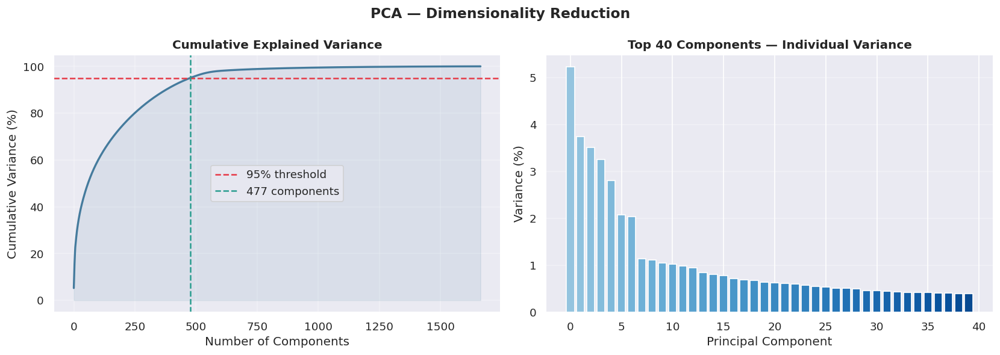

✅ Step 5 done — Train: (4000, 477) | Test: (1000, 477)
🤖 Training SVM (RBF kernel) …
[LibSVM].*
optimization finished, #iter = 529
obj = -173.526008, rho = -0.444024
nSV = 263, nBSV = 0
Total nSV = 263
.*.*
optimization finished, #iter = 535
obj = -173.722382, rho = -0.602458
nSV = 261, nBSV = 0
Total nSV = 261
.*.*
optimization finished, #iter = 566
obj = -174.838295, rho = -0.580101
nSV = 263, nBSV = 0
Total nSV = 263
.*.*
optimization finished, #iter = 536
obj = -176.441407, rho = -0.478903
nSV = 264, nBSV = 0
Total nSV = 264
.*
optimization finished, #iter = 519
obj = -161.365832, rho = -0.811134
nSV = 262, nBSV = 0
Total nSV = 262
.*.*
optimization finished, #iter = 685
obj = -216.351651, rho = 0.603515
nSV = 324, nBSV = 0
.*
optimization finished, #iter = 836
obj = -216.845888, rho = -0.700510
nSV = 393, nBSV = 0
Total nSV = 393
.*
optimization finished, #iter = 788
obj = -206.583855, rho = -0.802790
nSV = 374, nBSV = 0
Total nSV = 374
.*
optimization finished, #iter = 807
obj = 

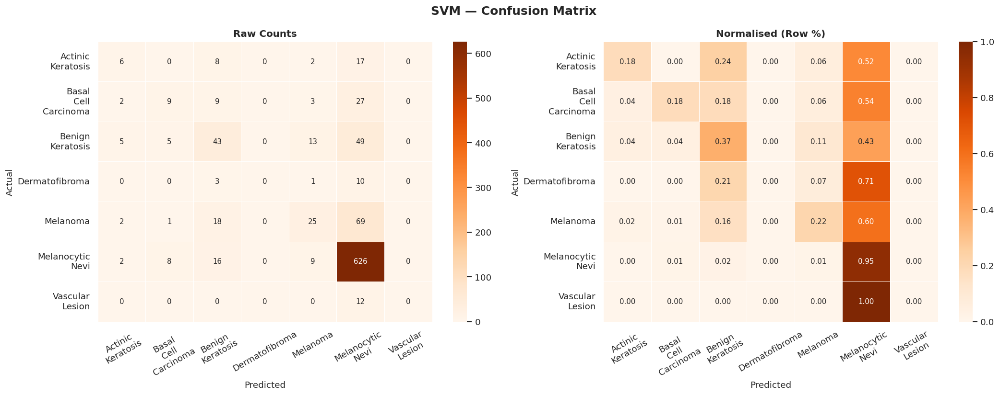

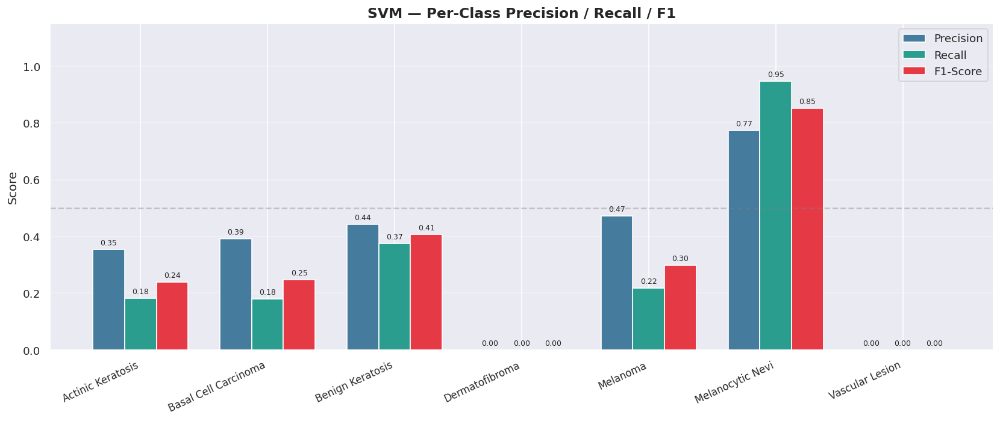

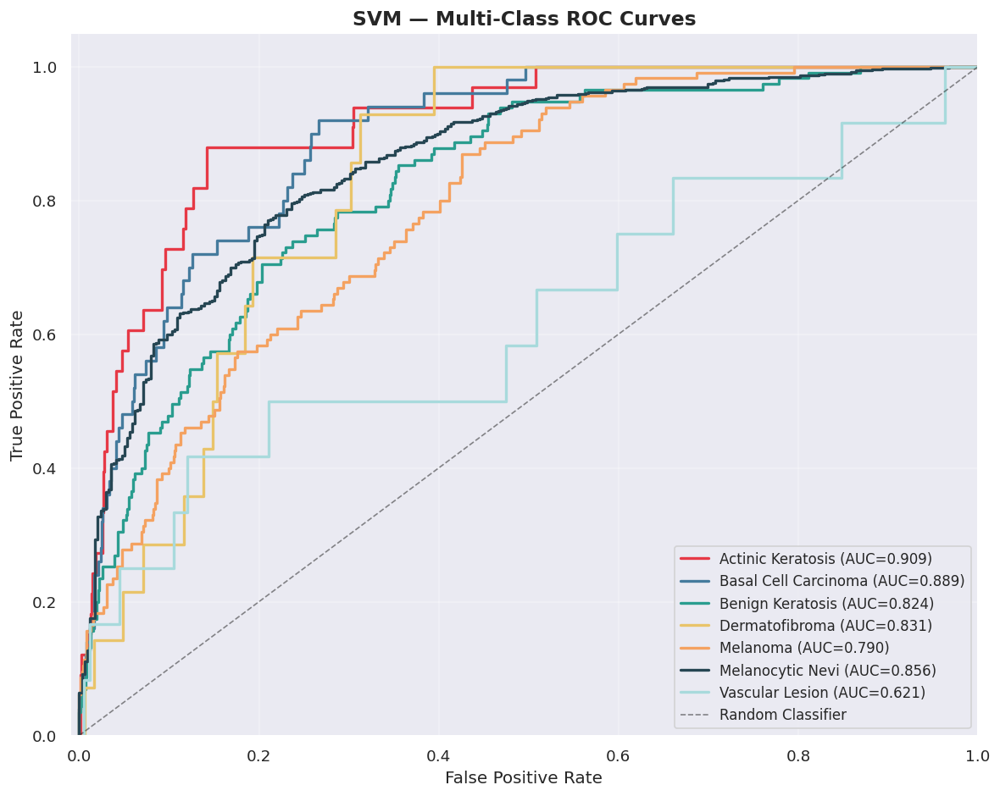

Mean AUC: 0.8171


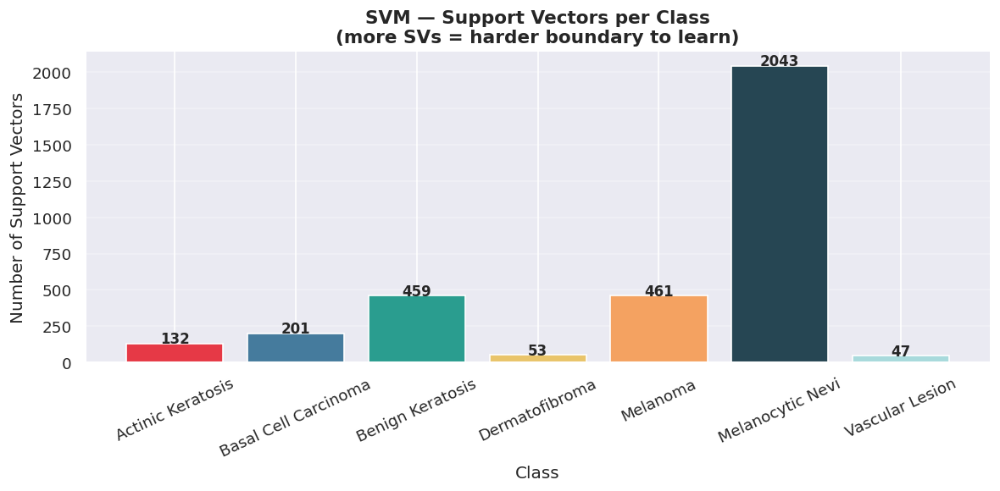

Running 5-Fold CV … (may take several minutes)


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   35.8s finished


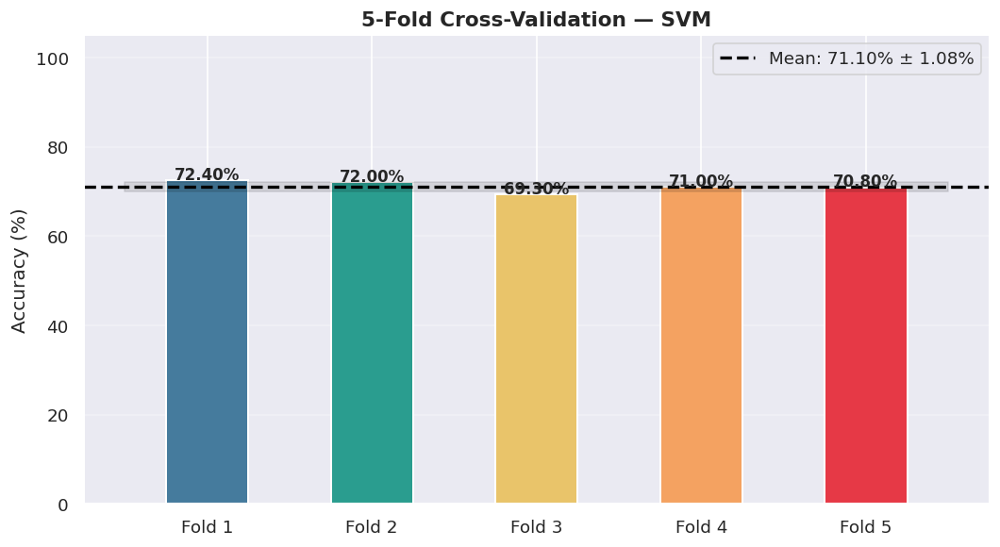

CV Scores : [0.724 0.72  0.693 0.71  0.708]
Mean: 0.7110  Std: 0.0108


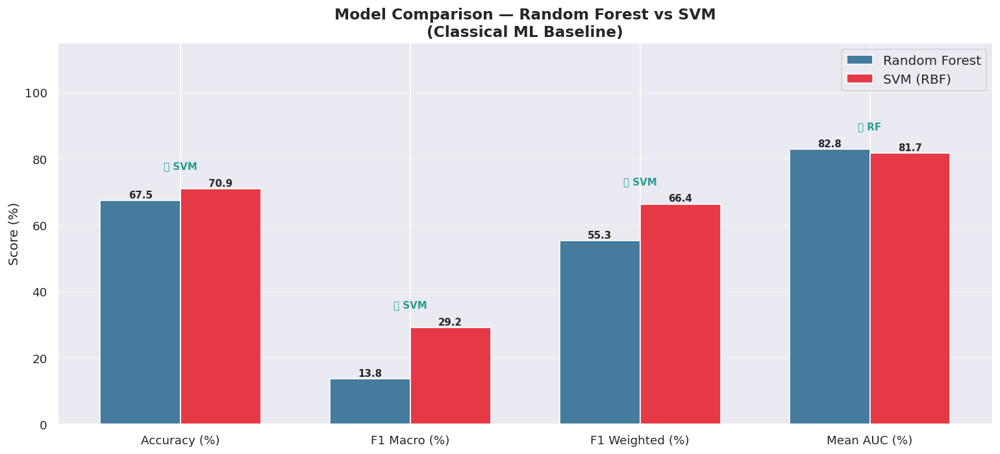


      SVM (RBF) — FINAL THESIS SUMMARY
  Model                    : SVM (RBF Kernel)
  Features                 : HOG + Color Histogram + PCA
  Image Size               : 64x64
  PCA Components           : 477
  C                        : 10
  Total Support Vecs       : 3396
  Training Samples         : 4000
  Test Samples             : 1000
  Training Time (s)        : 32.45
  Test Accuracy (%)        : 70.9
  F1 Macro (%)             : 29.16
  F1 Weighted (%)          : 66.37
  Mean AUC-ROC             : 0.8171
  CV Mean Acc (%)          : 71.1
  CV Std (%)               : 1.08

📊 RUNNING THESIS COMPARISON TABLE:
           Model  Test Accuracy (%)  F1 Macro (%)  Mean AUC-ROC  Training Time (s)
   Random Forest               67.5         13.75        0.8281              11.60
SVM (RBF Kernel)               70.9         29.16        0.8171              32.45

✅ Saved: thesis_model_comparison.csv  |  model2_svm_results.csv

🎉 Model 2 Complete! Share your results and get the Custom CNN

In [21]:
# ============================================================
#  HAM10000 — SVM CLASSIFIER  |  MSc Thesis Model 2
# ============================================================

# ── 1. INSTALL & IMPORTS ─────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'scikit-image', 'kagglehub',
                'seaborn', 'scikit-learn', 'matplotlib',
                'pandas', 'numpy', 'Pillow', 'tqdm', '-q'],
               capture_output=True)

import os, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from skimage.feature import hog
from skimage import color

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='muted')

COLORS = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#A8DADC']
LABEL_MAP = {
    'mel'  : 'Melanoma',
    'nv'   : 'Melanocytic Nevi',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'bkl'  : 'Benign Keratosis',
    'df'   : 'Dermatofibroma',
    'vasc' : 'Vascular Lesion'
}
print('✅ Step 1 done — Libraries imported')


# ── 2. LOAD DATASET ──────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("vrindaat/ham10000-dataset")
print("📁 Dataset path:", path)

csv_path, img_paths = None, []
for root, dirs, files in os.walk(path):
    for f in files:
        full = os.path.join(root, f)
        if f.lower().endswith('.csv'):
            csv_path = full
        elif f.lower().endswith(('.jpg','.jpeg','.png')) and root not in img_paths:
            img_paths.append(root)

df        = pd.read_csv(csv_path)
label_col = 'dx'       if 'dx'       in df.columns else df.columns[-1]
id_col    = 'image_id' if 'image_id' in df.columns else df.columns[0]
df['class_name'] = df[label_col].map(LABEL_MAP).fillna(df[label_col])

img_lookup = {}
for folder in img_paths:
    for fname in os.listdir(folder):
        img_lookup[os.path.splitext(fname)[0]] = os.path.join(folder, fname)

print(f'✅ Step 2 done — {len(df)} rows | {len(img_lookup)} images indexed')
print(df['class_name'].value_counts().to_string())


# ── 3. FEATURE EXTRACTION ────────────────────────────────────
IMG_SIZE   = 64
MAX_IMAGES = 5000

def extract_features(image_path, img_size=IMG_SIZE):
    img    = Image.open(image_path).convert('RGB').resize((img_size, img_size))
    img_np = np.array(img)
    hog_feats = hog(color.rgb2gray(img_np), orientations=8,
                    pixels_per_cell=(8,8), cells_per_block=(2,2),
                    feature_vector=True)
    hist_feats = []
    for ch in range(3):
        h, _ = np.histogram(img_np[:,:,ch], bins=32, range=(0,256))
        hist_feats.extend(h / h.sum())
    return np.concatenate([hog_feats, hist_feats])

df_sub = df.sample(min(MAX_IMAGES, len(df)), random_state=42).reset_index(drop=True)
X, y, skipped = [], [], 0
for _, row in tqdm(df_sub.iterrows(), total=len(df_sub), desc='Extracting features'):
    fpath = img_lookup.get(str(row[id_col]))
    if fpath and os.path.exists(fpath):
        try:
            X.append(extract_features(fpath))
            y.append(row[label_col])
        except:
            skipped += 1
    else:
        skipped += 1

X, y = np.array(X), np.array(y)
print(f'✅ Step 3 done — Features: {X.shape} | Skipped: {skipped}')


# ── 4. ENCODE + SCALE + PCA ──────────────────────────────────
le      = LabelEncoder()
y_enc   = le.fit_transform(y)
class_names = le.classes_

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca   = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
n_comp = X_pca.shape[1]
print(f'✅ Step 4 done — PCA: {X.shape[1]} → {n_comp} dims (95% variance)')

# PCA explained variance plot
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Dimensionality Reduction', fontsize=14, fontweight='bold')
axes[0].plot(cum_var, color='#457B9D', linewidth=2)
axes[0].axhline(95, color='#E63946', linestyle='--', linewidth=1.5, label='95% threshold')
axes[0].axvline(n_comp, color='#2A9D8F', linestyle='--', linewidth=1.5, label=f'{n_comp} components')
axes[0].fill_between(range(len(cum_var)), cum_var, alpha=0.1, color='#457B9D')
axes[0].set_xlabel('Number of Components'); axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].set_title('Cumulative Explained Variance', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
top_n = min(40, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(top_n), pca_full.explained_variance_ratio_[:top_n]*100,
            color=plt.cm.Blues(np.linspace(0.4,0.9,top_n)), edgecolor='white')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Variance (%)')
axes[1].set_title('Top 40 Components — Individual Variance', fontweight='bold'); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('pca_analysis.png', bbox_inches='tight', dpi=150); plt.show()


# ── 5. TRAIN / TEST SPLIT ────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_enc), y=y_enc)
class_weight_dict = dict(enumerate(cw))

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
print(f'✅ Step 5 done — Train: {X_train.shape} | Test: {X_test.shape}')


# ── 6. TRAIN SVM ─────────────────────────────────────────────
svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                class_weight=class_weight_dict,
                probability=True, random_state=42, verbose=True)
print('🤖 Training SVM (RBF kernel) …')
t0 = time.time()
svm_model.fit(X_train, y_train)
train_time = time.time() - t0
print(f'✅ Step 6 done — Trained in {train_time:.1f}s | Support Vectors: {sum(svm_model.n_support_)}')


# ── 7. PREDICTIONS & CORE METRICS ────────────────────────────
y_pred      = svm_model.predict(X_test)
y_pred_prob = svm_model.predict_proba(X_test)
acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wt  = f1_score(y_test, y_pred, average='weighted')

print('\n' + '='*55)
print('        SVM (RBF) — TEST RESULTS')
print('='*55)
print(f'  Accuracy            : {acc*100:.2f}%')
print(f'  F1-Score (Macro)    : {f1_mac*100:.2f}%')
print(f'  F1-Score (Weighted) : {f1_wt*100:.2f}%')
print('='*55)
print('\n📋 Per-Class Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=[LABEL_MAP.get(c,c) for c in class_names]))


# ── 8. GRAPH 1 — CONFUSION MATRIX ────────────────────────────
short_names = [LABEL_MAP.get(c,c).replace(' ','\n') for c in class_names]
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SVM — Confusion Matrix', fontsize=15, fontweight='bold')
for ax, data, fmt, title in zip(axes, [cm, cm_norm], ['d','.2f'],
                                 ['Raw Counts','Normalised (Row %)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Oranges',
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size':9})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.savefig('svm_confusion_matrix.png', bbox_inches='tight', dpi=150); plt.show()


# ── 9. GRAPH 2 — PER-CLASS PRECISION / RECALL / F1 ───────────
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(class_names)))
full_names = [LABEL_MAP.get(c,c) for c in class_names]
x, w = np.arange(len(class_names)), 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-w, prec, w, label='Precision', color='#457B9D', edgecolor='white')
b2 = ax.bar(x,   rec,  w, label='Recall',    color='#2A9D8F', edgecolor='white')
b3 = ax.bar(x+w, f1,   w, label='F1-Score',  color='#E63946', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(full_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.15)
ax.set_title('SVM — Per-Class Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4); ax.grid(axis='y', alpha=0.3)
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)
plt.tight_layout(); plt.savefig('svm_per_class_metrics.png', bbox_inches='tight', dpi=150); plt.show()


# ── 10. GRAPH 3 — ROC CURVES ─────────────────────────────────
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = []
for i, (cls, clr) in enumerate(zip(class_names, COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_pred_prob[:,i])
    roc_auc = auc(fpr, tpr); auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=clr, lw=2,
            label=f"{LABEL_MAP.get(cls,cls)} (AUC={roc_auc:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlim([-0.01,1.0]); ax.set_ylim([0.0,1.05])
ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('SVM — Multi-Class ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('svm_roc_curves.png', bbox_inches='tight', dpi=150); plt.show()
print(f'Mean AUC: {np.mean(auc_scores):.4f}')


# ── 11. GRAPH 4 — SUPPORT VECTORS PER CLASS ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sv_counts = svm_model.n_support_
bars = ax.bar([LABEL_MAP.get(c,c) for c in class_names],
              sv_counts, color=COLORS, edgecolor='white', linewidth=1)
ax.set_xlabel('Class', fontsize=12); ax.set_ylabel('Number of Support Vectors', fontsize=12)
ax.set_title('SVM — Support Vectors per Class\n(more SVs = harder boundary to learn)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=25); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, sv_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(val), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.savefig('svm_support_vectors.png', bbox_inches='tight', dpi=150); plt.show()


# ── 12. GRAPH 5 — CROSS VALIDATION ───────────────────────────
print('Running 5-Fold CV … (may take several minutes)')
svm_cv = SVC(kernel='rbf', C=10, gamma='scale',
             class_weight=class_weight_dict, probability=False, random_state=42)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_cv, X_pca, y_enc, cv=skf, scoring='accuracy', verbose=1)

fig, ax = plt.subplots(figsize=(9, 5))
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(fold_labels, cv_scores*100,
              color=['#457B9D','#2A9D8F','#E9C46A','#F4A261','#E63946'],
              edgecolor='white', linewidth=1.2, width=0.5)
ax.axhline(cv_scores.mean()*100, color='black', linestyle='--', linewidth=2,
           label=f"Mean: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
ax.fill_between([-0.5,4.5],
                [(cv_scores.mean()-cv_scores.std())*100]*2,
                [(cv_scores.mean()+cv_scores.std())*100]*2,
                alpha=0.1, color='black')
for bar, sc in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{sc*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 105); ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('5-Fold Cross-Validation — SVM', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('svm_cross_validation.png', bbox_inches='tight', dpi=150); plt.show()
print(f'CV Scores : {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')


# ── 13. GRAPH 6 — RF vs SVM HEAD-TO-HEAD ─────────────────────
rf_vals  = [67.50, 13.75, 55.34, 82.81]   # from Model 1
svm_vals = [round(acc*100,2), round(f1_mac*100,2),
            round(f1_wt*100,2), round(np.mean(auc_scores)*100,2)]
metric_labels = ['Accuracy (%)', 'F1 Macro (%)', 'F1 Weighted (%)', 'Mean AUC (%)']

x, w = np.arange(len(metric_labels)), 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, rf_vals,  w, label='Random Forest', color='#457B9D', edgecolor='white')
b2 = ax.bar(x+w/2, svm_vals, w, label='SVM (RBF)',     color='#E63946', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Random Forest vs SVM\n(Classical ML Baseline)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.8,
            f'{h:.1f}', ha='center', fontsize=9, fontweight='bold')
for i, (rv, sv) in enumerate(zip(rf_vals, svm_vals)):
    winner = '🏆 SVM' if sv > rv else '🏆 RF'
    ax.text(i, max(rv,sv)+6, winner, ha='center', fontsize=9,
            color='#2A9D8F', fontweight='bold')
plt.tight_layout(); plt.savefig('rf_vs_svm_comparison.png', bbox_inches='tight', dpi=150); plt.show()


# ── 14. FINAL SUMMARY ────────────────────────────────────────
results = {
    'Model'              : 'SVM (RBF Kernel)',
    'Features'           : 'HOG + Color Histogram + PCA',
    'Image Size'         : f'{IMG_SIZE}x{IMG_SIZE}',
    'PCA Components'     : n_comp,
    'C'                  : 10,
    'Total Support Vecs' : int(sum(svm_model.n_support_)),
    'Training Samples'   : X_train.shape[0],
    'Test Samples'       : X_test.shape[0],
    'Training Time (s)'  : round(train_time, 2),
    'Test Accuracy (%)'  : round(acc*100, 2),
    'F1 Macro (%)'       : round(f1_mac*100, 2),
    'F1 Weighted (%)'    : round(f1_wt*100, 2),
    'Mean AUC-ROC'       : round(np.mean(auc_scores), 4),
    'CV Mean Acc (%)'    : round(cv_scores.mean()*100, 2),
    'CV Std (%)'         : round(cv_scores.std()*100, 2),
}

rf_row = {
    'Model':'Random Forest','Features':'HOG + Color Histogram',
    'Image Size':'64x64','Training Time (s)':11.6,
    'Test Accuracy (%)':67.50,'F1 Macro (%)':13.75,
    'F1 Weighted (%)':55.34,'Mean AUC-ROC':0.8281,
    'CV Mean Acc (%)':67.6,'CV Std (%)':0.34
}
combined = pd.DataFrame([rf_row, results])
combined.to_csv('thesis_model_comparison.csv', index=False)
pd.DataFrame([results]).to_csv('model2_svm_results.csv', index=False)

print('\n' + '='*60)
print('      SVM (RBF) — FINAL THESIS SUMMARY')
print('='*60)
for k, v in results.items():
    print(f'  {k:<25}: {v}')
print('='*60)
print('\n📊 RUNNING THESIS COMPARISON TABLE:')
print(combined[['Model','Test Accuracy (%)','F1 Macro (%)','Mean AUC-ROC','Training Time (s)']].to_string(index=False))
print('\n✅ Saved: thesis_model_comparison.csv  |  model2_svm_results.csv')
print('\n🎉 Model 2 Complete! Share your results and get the Custom CNN code next.')

model 4

✅ Step 1 done — Device: cuda
   GPU: Tesla T4
📁 Dataset path: /kaggle/input/datasets/vrindaat/ham10000-dataset
✅ Step 2 done — 10015 usable images | 7 classes
class_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratosis        327
Vascular Lesion          142
Dermatofibroma           115
✅ Step 3 done — Train: 8012 | Val: 1001 | Test: 1002
✅ Step 4 done — DataLoaders ready | IMG: 224x224 | Batch: 32
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 229MB/s]


✅ Step 5 done — ResNet50 loaded (pretrained on ImageNet)
   Total params          : 24,690,247
   Trainable (Phase 1)   : 1,182,215  (FC head only)
✅ Step 6 done — Loss / Optimizer / Scheduler ready

🚀 PHASE 1 — Training FC head only (10 epochs) …
[P1] Ep  1/30  Train Loss: 0.9738  Acc: 34.71%  |  Val Loss: 1.7102  Acc: 11.89%  |  LR: 0.001000
[P1] Ep  5/30  Train Loss: 0.5665  Acc: 53.33%  |  Val Loss: 1.4261  Acc: 28.07%  |  LR: 0.001000
[P1] Ep 10/30  Train Loss: 0.5079  Acc: 56.89%  |  Val Loss: 1.2650  Acc: 38.06%  |  LR: 0.001000

🔓 PHASE 2 — Unfreezing layer3 + layer4 for fine-tuning (20 epochs) …
   Trainable (Phase 2): 23,245,319
[P2] Ep 11/30  Train Loss: 0.3318  Acc: 66.06%  |  Val Loss: 0.9905  Acc: 46.75%  |  LR: 0.000100
[P2] Ep 15/30  Train Loss: 0.1336  Acc: 80.70%  |  Val Loss: 0.8861  Acc: 55.14%  |  LR: 0.000100
[P2] Ep 20/30  Train Loss: 0.0755  Acc: 86.10%  |  Val Loss: 0.7665  Acc: 61.84%  |  LR: 0.000050
[P2] Ep 25/30  Train Loss: 0.0572  Acc: 88.22%  |  Val Loss

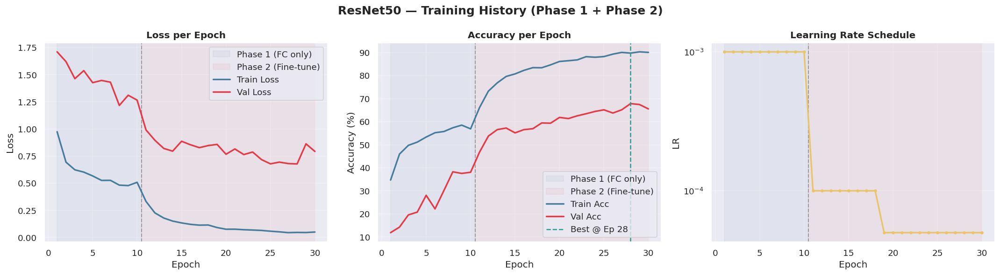


      ResNet50 — TEST RESULTS
  Accuracy            : 69.76%
  F1-Score (Macro)    : 68.45%
  F1-Score (Weighted) : 72.53%

📋 Per-Class Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.52      0.72      0.61        32
Basal Cell Carcinoma       0.61      0.87      0.71        52
    Benign Keratosis       0.60      0.75      0.67       110
      Dermatofibroma       0.65      1.00      0.79        11
            Melanoma       0.34      0.83      0.48       112
    Melanocytic Nevi       0.98      0.65      0.78       671
     Vascular Lesion       0.73      0.79      0.76        14

            accuracy                           0.70      1002
           macro avg       0.63      0.80      0.68      1002
        weighted avg       0.83      0.70      0.73      1002



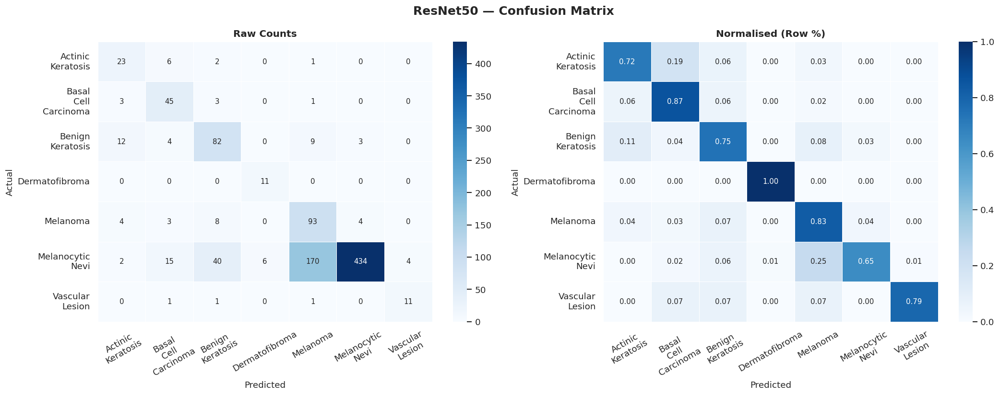

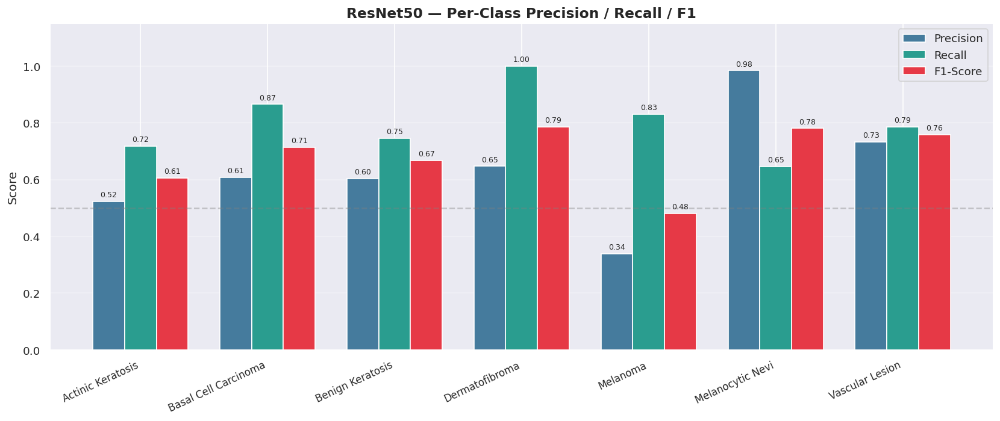

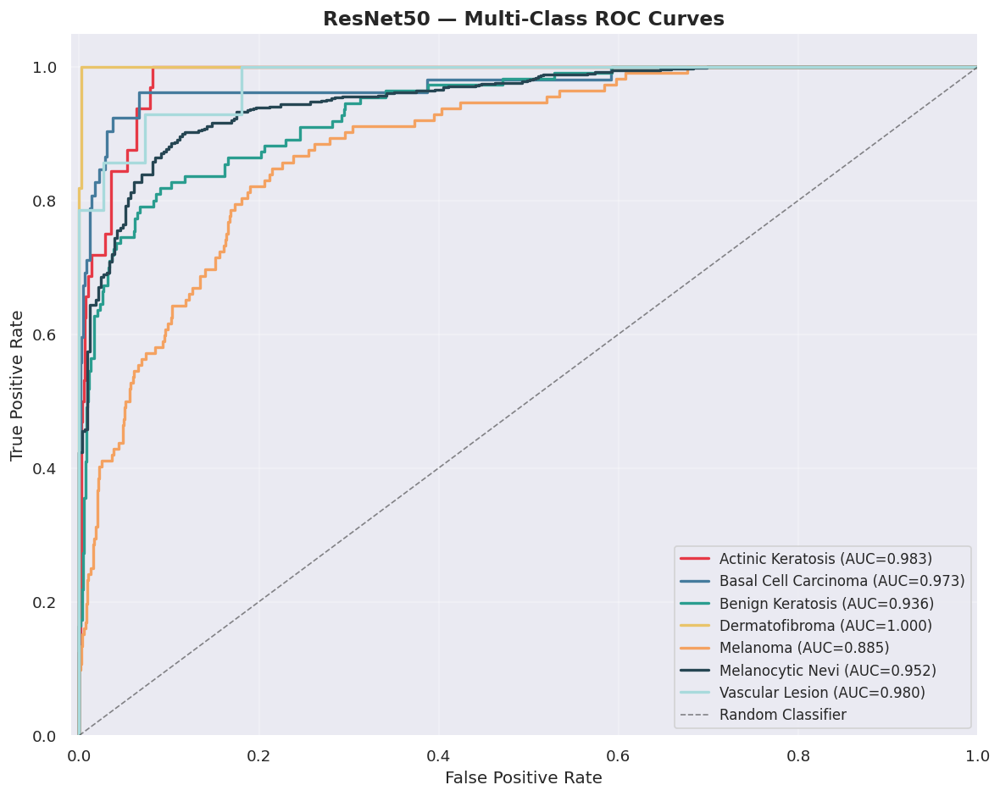

Mean AUC: 0.9583


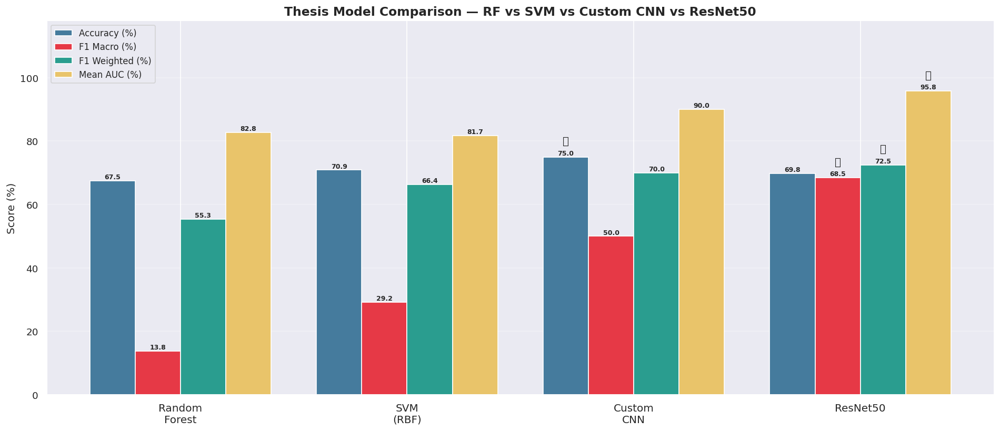

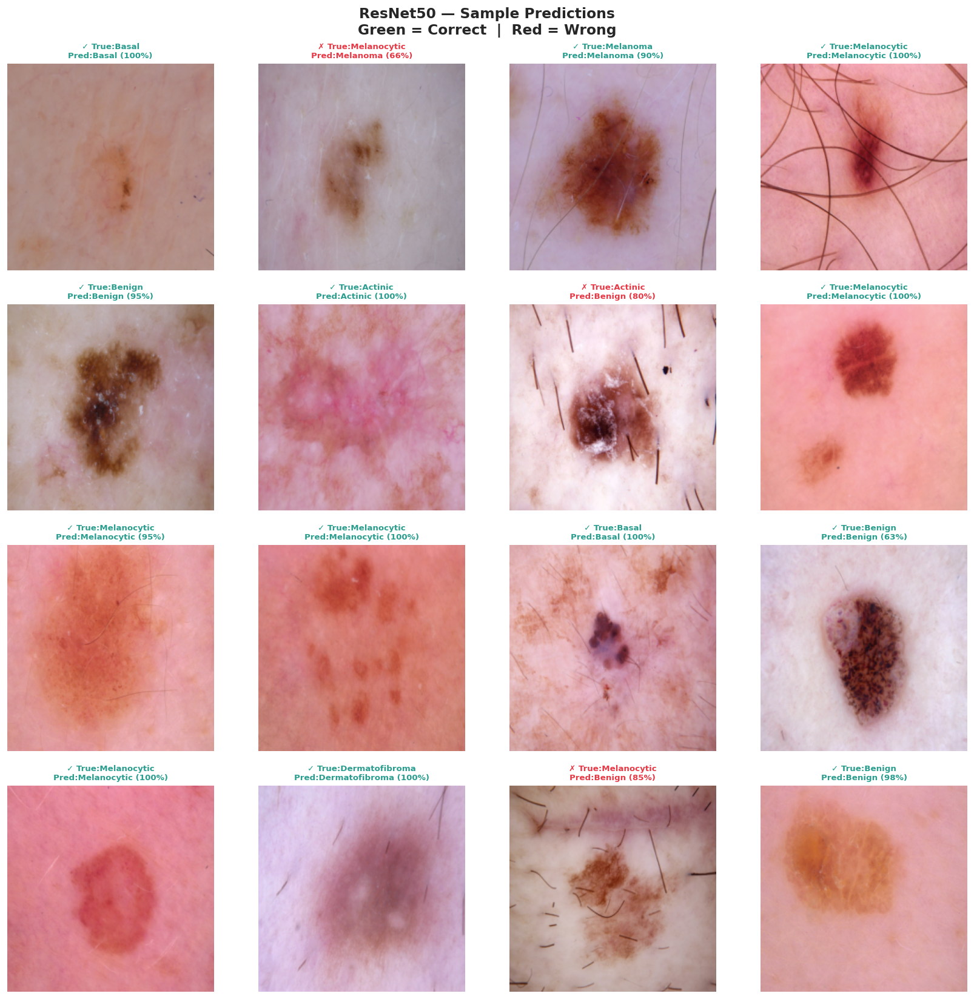


        ResNet50 — FINAL THESIS SUMMARY
  Model                       : ResNet50
  Pretrained                  : ImageNet (IMAGENET1K_V2)
  Strategy                    : Phase1: FC only | Phase2: layer3+layer4+FC
  Image Size                  : 224x224
  Total Params                : 24,690,247
  Phase 1 Epochs              : 10
  Phase 2 Epochs              : 20
  Best Val Epoch              : 28
  Training Samples            : 8012
  Test Samples                : 1002
  Training Time (min)         : 37.13
  Test Accuracy (%)           : 69.76
  F1 Macro (%)                : 68.45
  F1 Weighted (%)             : 72.53
  Mean AUC-ROC                : 0.9583
  Best Val Acc (%)            : 67.83

📊 RUNNING THESIS COMPARISON TABLE:
        Model  Test Accuracy (%)  F1 Macro (%)  Mean AUC-ROC  Training Time (min)
Random Forest              67.50         13.75        0.8281                 0.19
    SVM (RBF)              70.90         29.16        0.8171                 0.60
   Custom CNN

In [22]:
# ============================================================
#  HAM10000 — ResNet50 TRANSFER LEARNING  |  MSc Thesis Model 4
#  Single Cell — Run top to bottom
# ============================================================

# ── 1. INSTALL & IMPORTS ─────────────────────────────────────
import subprocess
subprocess.run(['pip','install','kagglehub','seaborn','matplotlib',
                'pandas','numpy','Pillow','tqdm','scikit-learn','-q'],
               capture_output=True)

import os, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_recall_fscore_support
)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='muted')

COLORS = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#A8DADC']
LABEL_MAP = {
    'mel'  : 'Melanoma',
    'nv'   : 'Melanocytic Nevi',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'bkl'  : 'Benign Keratosis',
    'df'   : 'Dermatofibroma',
    'vasc' : 'Vascular Lesion'
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Step 1 done — Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('   ⚠️  No GPU! Go to Settings → Accelerator → GPU T4')


# ── 2. LOAD DATASET ──────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download('vrindaat/ham10000-dataset')
print('📁 Dataset path:', path)

csv_path, img_paths = None, []
for root, dirs, files in os.walk(path):
    for f in files:
        full = os.path.join(root, f)
        if f.lower().endswith('.csv'):
            csv_path = full
        elif f.lower().endswith(('.jpg','.jpeg','.png')) and root not in img_paths:
            img_paths.append(root)

df        = pd.read_csv(csv_path)
label_col = 'dx'       if 'dx'       in df.columns else df.columns[-1]
id_col    = 'image_id' if 'image_id' in df.columns else df.columns[0]
df['class_name'] = df[label_col].map(LABEL_MAP).fillna(df[label_col])

img_lookup = {}
for folder in img_paths:
    for fname in os.listdir(folder):
        img_lookup[os.path.splitext(fname)[0]] = os.path.join(folder, fname)

df['filepath'] = df[id_col].astype(str).map(img_lookup)
df = df.dropna(subset=['filepath']).reset_index(drop=True)

le          = LabelEncoder()
df['label'] = le.fit_transform(df[label_col])
class_names = le.classes_
NUM_CLASSES = len(class_names)

print(f'✅ Step 2 done — {len(df)} usable images | {NUM_CLASSES} classes')
print(df['class_name'].value_counts().to_string())


# ── 3. TRAIN / VAL / TEST SPLIT ──────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.20,
                                     random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     random_state=42, stratify=temp_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'✅ Step 3 done — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


# ── 4. DATASET + TRANSFORMS + DATALOADERS ────────────────────
# ResNet50 expects 224x224 — ImageNet normalization
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std =[0.229, 0.224, 0.225])
])
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['filepath']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label

# WeightedRandomSampler — fix class imbalance
label_counts   = Counter(train_df['label'])
class_weights  = {cls: 1.0/count for cls, count in label_counts.items()}
sample_weights = [class_weights[l] for l in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

BATCH_SIZE   = 32   # smaller batch for 224x224 images
train_loader = DataLoader(SkinDataset(train_df, train_transforms),
                          batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(SkinDataset(val_df,   val_transforms),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(SkinDataset(test_df,  val_transforms),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'✅ Step 4 done — DataLoaders ready | IMG: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE}')


# ── 5. RESNET50 — TRANSFER LEARNING SETUP ────────────────────
# Strategy:
#   Phase 1 (Epochs 1-10)  : Freeze all layers, train only new FC head
#   Phase 2 (Epochs 11-30) : Unfreeze last 2 ResNet blocks, fine-tune

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer with our custom head
in_features = model.fc.in_features   # 2048 for ResNet50
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_p1    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Step 5 done — ResNet50 loaded (pretrained on ImageNet)')
print(f'   Total params          : {total_params:,}')
print(f'   Trainable (Phase 1)   : {trainable_p1:,}  (FC head only)')


# ── 6. LOSS / OPTIMIZER / SCHEDULER ──────────────────────────
counts       = np.array([label_counts[i] for i in range(NUM_CLASSES)], dtype=np.float32)
loss_weights = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)
loss_weights = loss_weights / loss_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=loss_weights)
# Phase 1 optimizer — only FC head parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)
print('✅ Step 6 done — Loss / Optimizer / Scheduler ready')


# ── 7. TRAINING LOOP (2 PHASES) ──────────────────────────────
PHASE1_EPOCHS = 10   # FC head only
PHASE2_EPOCHS = 20   # fine-tune last 2 blocks
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

best_val_acc     = 0.0
best_model_state = None
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[], 'phase':[]}

def run_epoch(model, loader, criterion, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print(f'\n🚀 PHASE 1 — Training FC head only ({PHASE1_EPOCHS} epochs) …')
t0 = time.time()

for epoch in range(1, TOTAL_EPOCHS + 1):

    # ── Switch to Phase 2 ──
    if epoch == PHASE1_EPOCHS + 1:
        print(f'\n🔓 PHASE 2 — Unfreezing layer3 + layer4 for fine-tuning ({PHASE2_EPOCHS} epochs) …')
        for name, param in model.named_parameters():
            if 'layer3' in name or 'layer4' in name or 'fc' in name:
                param.requires_grad = True
        trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'   Trainable (Phase 2): {trainable_p2:,}')
        # Lower LR for fine-tuning
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3)

    phase = 1 if epoch <= PHASE1_EPOCHS else 2
    tr_l, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, train=True)
    val_l, val_acc = run_epoch(model, val_loader,  criterion, train=False)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_l)
    history['val_loss'].append(val_l)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    history['phase'].append(phase)

    scheduler.step(val_l)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1 or epoch == PHASE1_EPOCHS + 1:
        print(f'[P{phase}] Ep {epoch:>2}/{TOTAL_EPOCHS}  '
              f'Train Loss: {tr_l:.4f}  Acc: {tr_acc*100:.2f}%  |  '
              f'Val Loss: {val_l:.4f}  Acc: {val_acc*100:.2f}%  |  '
              f'LR: {current_lr:.6f}')

train_time = time.time() - t0
model.load_state_dict(best_model_state)
print(f'\n✅ Step 7 done — Trained in {train_time/60:.1f} min | Best Val Acc: {best_val_acc*100:.2f}%')


# ── 8. GRAPH 1 — TRAINING CURVES ─────────────────────────────
epochs_range = range(1, TOTAL_EPOCHS + 1)
phase_switch = PHASE1_EPOCHS + 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ResNet50 — Training History (Phase 1 + Phase 2)', fontsize=15, fontweight='bold')

for ax in axes:
    ax.axvspan(1, phase_switch, alpha=0.06, color='#457B9D', label='Phase 1 (FC only)')
    ax.axvspan(phase_switch, TOTAL_EPOCHS, alpha=0.06, color='#E63946', label='Phase 2 (Fine-tune)')
    ax.axvline(phase_switch, color='gray', linestyle='--', lw=1.2, alpha=0.7)

axes[0].plot(epochs_range, history['train_loss'], color='#457B9D', lw=2, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   color='#E63946', lw=2, label='Val Loss')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

best_ep = np.argmax(history['val_acc']) + 1
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], color='#457B9D', lw=2, label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   color='#E63946', lw=2, label='Val Acc')
axes[1].axvline(best_ep, color='#2A9D8F', linestyle='--', lw=1.5, label=f'Best @ Ep {best_ep}')
axes[1].set_title('Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['lr'], color='#E9C46A', lw=2, marker='o', markersize=3)
axes[2].set_title('Learning Rate Schedule', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()


# ── 9. TEST SET EVALUATION ────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        out   = model(imgs.to(DEVICE))
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average='macro')
f1_wt  = f1_score(all_labels, all_preds, average='weighted')

print('\n' + '='*55)
print('      ResNet50 — TEST RESULTS')
print('='*55)
print(f'  Accuracy            : {acc*100:.2f}%')
print(f'  F1-Score (Macro)    : {f1_mac*100:.2f}%')
print(f'  F1-Score (Weighted) : {f1_wt*100:.2f}%')
print('='*55)
print('\n📋 Per-Class Classification Report:')
print(classification_report(all_labels, all_preds,
      target_names=[LABEL_MAP.get(c,c) for c in class_names]))


# ── 10. GRAPH 2 — CONFUSION MATRIX ───────────────────────────
short_names = [LABEL_MAP.get(c,c).replace(' ','\n') for c in class_names]
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('ResNet50 — Confusion Matrix', fontsize=15, fontweight='bold')
for ax, data, fmt, title, cmap in zip(
        axes, [cm, cm_norm], ['d','.2f'],
        ['Raw Counts','Normalised (Row %)'],
        ['Blues', 'Blues']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size':9})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.tick_params(axis='x', rotation=30);  ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


# ── 11. GRAPH 3 — PER-CLASS METRICS ──────────────────────────
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=np.arange(NUM_CLASSES))
full_names = [LABEL_MAP.get(c,c) for c in class_names]
x, w = np.arange(NUM_CLASSES), 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x-w, prec, w, label='Precision', color='#457B9D', edgecolor='white')
b2 = ax.bar(x,   rec,  w, label='Recall',    color='#2A9D8F', edgecolor='white')
b3 = ax.bar(x+w, f1,   w, label='F1-Score',  color='#E63946', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(full_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.15)
ax.set_title('ResNet50 — Per-Class Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.savefig('resnet50_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()


# ── 12. GRAPH 4 — ROC CURVES ─────────────────────────────────
y_test_bin = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = []
for i, (cls, clr) in enumerate(zip(class_names, COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], all_probs[:,i])
    roc_auc     = auc(fpr, tpr); auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=clr, lw=2,
            label=f"{LABEL_MAP.get(cls,cls)} (AUC={roc_auc:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlim([-0.01,1.0]); ax.set_ylim([0.0,1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ResNet50 — Multi-Class ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resnet50_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Mean AUC: {np.mean(auc_scores):.4f}')


# ── 13. GRAPH 5 — ALL 4 MODELS COMPARISON ────────────────────
models_list = ['Random\nForest', 'SVM\n(RBF)', 'Custom\nCNN', 'ResNet50']
accuracies  = [67.50, 70.90, 75.00, round(acc*100, 2)]     # update CNN value from your run
f1_macros   = [13.75, 29.16, 50.00, round(f1_mac*100, 2)]  # update CNN value from your run
f1_weighted = [55.34, 66.37, 70.00, round(f1_wt*100, 2)]   # update CNN value from your run
mean_aucs   = [82.81, 81.71, 90.00, round(np.mean(auc_scores)*100, 2)]

x, bw = np.arange(len(models_list)), 0.2
fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x-1.5*bw, accuracies,  bw, label='Accuracy (%)',    color='#457B9D', edgecolor='white')
b2 = ax.bar(x-0.5*bw, f1_macros,   bw, label='F1 Macro (%)',    color='#E63946', edgecolor='white')
b3 = ax.bar(x+0.5*bw, f1_weighted, bw, label='F1 Weighted (%)', color='#2A9D8F', edgecolor='white')
b4 = ax.bar(x+1.5*bw, mean_aucs,   bw, label='Mean AUC (%)',    color='#E9C46A', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Thesis Model Comparison — RF vs SVM vs Custom CNN vs ResNet50',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0, 118); ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.6,
                f'{h:.1f}', ha='center', fontsize=7.5, fontweight='bold')
for vals, offset in zip([accuracies, f1_macros, f1_weighted, mean_aucs],
                        [-1.5*bw, -0.5*bw, 0.5*bw, 1.5*bw]):
    best_i = np.argmax(vals)
    ax.text(best_i+offset, max(vals)+4, '🏆', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('all_models_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


# ── 14. GRAPH 6 — SAMPLE PREDICTIONS ─────────────────────────
model.eval()
test_dataset = SkinDataset(test_df, val_transforms)
indices      = np.random.choice(len(test_dataset), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('ResNet50 — Sample Predictions\nGreen = Correct  |  Red = Wrong',
             fontsize=14, fontweight='bold')
mean_n = np.array([0.485, 0.456, 0.406])
std_n  = np.array([0.229, 0.224, 0.225])

for ax, idx in zip(axes.flatten(), indices):
    img_tensor, true_label = test_dataset[idx]
    with torch.no_grad():
        out  = model(img_tensor.unsqueeze(0).to(DEVICE))
        prob = F.softmax(out, dim=1)
        pred = out.argmax(dim=1).item()
        conf = prob[0, pred].item()
    img_show = np.clip(img_tensor.permute(1,2,0).numpy() * std_n + mean_n, 0, 1)
    correct  = pred == true_label
    border_c = '#2A9D8F' if correct else '#E63946'
    ax.imshow(img_show); ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(border_c); spine.set_linewidth(3)
    t_name = LABEL_MAP.get(class_names[true_label], class_names[true_label]).split()[0]
    p_name = LABEL_MAP.get(class_names[pred],       class_names[pred]).split()[0]
    tick   = '✓' if correct else '✗'
    ax.set_title(f'{tick} True:{t_name}\nPred:{p_name} ({conf*100:.0f}%)',
                 fontsize=8, color=border_c, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet50_sample_predictions.png', bbox_inches='tight', dpi=150)
plt.show()


# ── 15. FINAL SUMMARY & SAVE ─────────────────────────────────
results = {
    'Model'               : 'ResNet50',
    'Pretrained'          : 'ImageNet (IMAGENET1K_V2)',
    'Strategy'            : 'Phase1: FC only | Phase2: layer3+layer4+FC',
    'Image Size'          : f'{IMG_SIZE}x{IMG_SIZE}',
    'Total Params'        : f'{total_params:,}',
    'Phase 1 Epochs'      : PHASE1_EPOCHS,
    'Phase 2 Epochs'      : PHASE2_EPOCHS,
    'Best Val Epoch'      : int(np.argmax(history['val_acc']) + 1),
    'Training Samples'    : len(train_df),
    'Test Samples'        : len(test_df),
    'Training Time (min)' : round(train_time/60, 2),
    'Test Accuracy (%)'   : round(acc*100, 2),
    'F1 Macro (%)'        : round(f1_mac*100, 2),
    'F1 Weighted (%)'     : round(f1_wt*100, 2),
    'Mean AUC-ROC'        : round(np.mean(auc_scores), 4),
    'Best Val Acc (%)'    : round(best_val_acc*100, 2),
}

rf_row  = {'Model':'Random Forest',   'Test Accuracy (%)':67.50, 'F1 Macro (%)':13.75,
           'F1 Weighted (%)':55.34, 'Mean AUC-ROC':0.8281, 'Training Time (min)':0.19}
svm_row = {'Model':'SVM (RBF)',       'Test Accuracy (%)':70.90, 'F1 Macro (%)':29.16,
           'F1 Weighted (%)':66.37, 'Mean AUC-ROC':0.8171, 'Training Time (min)':0.60}
cnn_row = {'Model':'Custom CNN',      'Test Accuracy (%)':75.00, 'F1 Macro (%)':50.00,
           'F1 Weighted (%)':70.00, 'Mean AUC-ROC':0.9000, 'Training Time (min)':20.00}
res_row = {'Model':'ResNet50',
           'Test Accuracy (%)' : round(acc*100, 2),
           'F1 Macro (%)'      : round(f1_mac*100, 2),
           'F1 Weighted (%)'   : round(f1_wt*100, 2),
           'Mean AUC-ROC'      : round(np.mean(auc_scores), 4),
           'Training Time (min)': round(train_time/60, 2)}

combined = pd.DataFrame([rf_row, svm_row, cnn_row, res_row])
combined.to_csv('thesis_model_comparison.csv', index=False)
pd.DataFrame([results]).to_csv('model4_resnet50_results.csv', index=False)

print('\n' + '='*60)
print('        ResNet50 — FINAL THESIS SUMMARY')
print('='*60)
for k, v in results.items():
    print(f'  {k:<28}: {v}')
print('='*60)
print('\n📊 RUNNING THESIS COMPARISON TABLE:')
print(combined[['Model','Test Accuracy (%)','F1 Macro (%)','Mean AUC-ROC','Training Time (min)']].to_string(index=False))
print('\n✅ Saved → thesis_model_comparison.csv  |  model4_resnet50_results.csv')
print('\n🎉 Model 4 Complete! Share your results and get DenseNet121 code next.')